<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/depmap/05_mutasyon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bağımlılığın nedeni: mutasyonla ilişkilendirmek

4.4 bir soruyla bitti: bağırsak hatları CTNNB1'e neden bağımlı? Adres tablosu "hangi dokuda" sorusunu cevapladı, "neden" sorusunu açık bıraktı. Bu defterde bağımlılık skorlarını mutasyon verisiyle birleştirip nedene bir adım yaklaşıyoruz.

Drive'daki proje klasöründe iki dosya gerekiyor: **OmicsSomaticMutationsMatrixHotspot.csv** (DepMap 25Q2, All Data sekmesi) ve 4.1'de zaten indirdiğiniz **CRISPRGeneEffect.csv**.

Hotspot matrisinin gen sütunlarındaki değerler 0, 1 ya da 2: sıfır mutasyon yok demek; bir ve iki, hücrede bilinen bir onkojenik hotspot mutasyonu bulunduğunu gösterir (aradaki fark mutasyonun alel frekansıdır). "Hotspot" tanımı, mutasyonun COSMIC ve OncoKB gibi kataloglarda tekrar eden onkojenik pozisyonlarda olması demektir: rastgele bir değişiklik değil, işlev kazandırdığı bilinen bir değişiklik. Matris yalnız bu tür mutasyonların görüldüğü birkaç yüz geni içerir, genomun tamamını değil.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import re
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

KLASOR = '/content/drive/MyDrive/melisa-ile-biyoinformatik'
KOK = 'https://zenodo.org/records/22759375/files'
urllib.request.urlretrieve(f'{KOK}/depmap_ders_skorlar%20(1).csv?download=1', 'skorlar.csv')
urllib.request.urlretrieve(f'{KOK}/depmap_ders_kunye%20(1).csv?download=1', 'kunye.csv')

skor = pd.read_csv('skorlar.csv', index_col=0)
kunye = pd.read_csv('kunye.csv', index_col=0)
mut_ham = pd.read_csv(f'{KLASOR}/OmicsSomaticMutationsMatrixHotspot.csv')

print('skor:', skor.shape, '| satır adı örneği:', skor.index[0])
print('mutasyon dosyası:', mut_ham.shape)
print('ilk sütunlar:', list(mut_ham.columns[:6]))

Mounted at /content/drive
skor: (1208, 5000) | satır adı örneği: ACH-000029
mutasyon dosyası: (3044, 560)
ilk sütunlar: ['Unnamed: 0', 'SequencingID', 'ModelID', 'ModelConditionID', 'IsDefaultEntryForModel', 'IsDefaultEntryForMC']


## 1. Dosyayı doğru okumak

Bu dosya, skor matrisinden farklı bir biçimde geliyor ve buna dikkat etmezseniz analiz sessizce boş çıkar. İlk sütunları yazdırdığımızda görülüyor: satır adı olarak kullanılabilecek bir kimlik yok; onun yerine `SequencingID`, `ModelID`, `ModelConditionID`, `IsDefaultEntryForModel` gibi künye sütunları var ve gen sütunları bunlardan *sonra* başlıyor.

Üç düzeltme gerekiyor:

1. **Satır kimliği**: hücre hattı kimliği `ModelID` sütununda duruyor, onu satır adı yapıyoruz. Skor tablosunun satır adları da `ACH-` ile başlayan ModelID'ler olduğu için iki tablo ancak böyle eşleşir.
2. **Gen sütunlarını ayırmak**: gen sütunları `SEMBOL (EntrezID)` kalıbında. Künye sütunlarını elle saymak yerine bu kalıba uyanları seçiyoruz; dosyaya yeni bir künye sütunu eklenirse kod yine çalışır.
3. **Tekrarlayan satırlar**: aynı hücre hattının birden fazla dizileme kaydı olabilir (WES, WGS ayrı satırlar). `IsDefaultEntryForModel` sütunu, DepMap'in o hat için seçtiği kaydı işaretler; onunla süzüyoruz. Güvenlik için, süzmeden sonra hâlâ tekrar kalırsa `groupby(level=0).max()` ile birleştiriyoruz — herhangi bir kayıt mutasyon gösteriyorsa hattı mutant sayıyoruz.

In [2]:
kalip = re.compile(r'^\S.* \(\d+\)$')
gen_sutun = [c for c in mut_ham.columns if kalip.match(c)]
kunye_sutun = [c for c in mut_ham.columns if c not in gen_sutun]
print('gen sütunu:', len(gen_sutun), '| künye sütunu:', len(kunye_sutun), '->', kunye_sutun[:8])

bayrak = mut_ham['IsDefaultEntryForModel'].astype(str).str.lower().isin(['yes', 'true'])
print('varsayılan kayıt olarak işaretli satır:', int(bayrak.sum()), '/', len(mut_ham))

mut = mut_ham[bayrak].set_index('ModelID')[gen_sutun]
mut = mut.groupby(level=0).max()
print('model kimliğine indirgenmiş matris:', mut.shape)

ortak = skor.index.intersection(mut.index)
print('ortak hücre hattı:', len(ortak))

gen sütunu: 553 | künye sütunu: 7 -> ['Unnamed: 0', 'SequencingID', 'ModelID', 'ModelConditionID', 'IsDefaultEntryForModel', 'IsDefaultEntryForMC', 'ZNF781 (Unknown)']
varsayılan kayıt olarak işaretli satır: 1968 / 3044
model kimliğine indirgenmiş matris: (1968, 553)
ortak hücre hattı: 1208


## 2. Karşılaştırma fonksiyonu

`karsilastir` bir gen için iki grubu ayırır — o gende hotspot mutasyonu olan hatlar ve olmayanlar — ve her grubun medyan bağımlılık skorunu yazar. İki medyan arasındaki fark bu defterin temel ölçüsü.

In [3]:
def bul(tablo, sembol):
    e = [c for c in tablo.columns if c.split(' ')[0] == sembol]
    return e[0] if e else None

def karsilastir(sembol, yaz=True):
    sc, mc = bul(skor, sembol), bul(mut, sembol)
    if sc is None or mc is None:
        if yaz:
            print(f'{sembol}: {"skor" if sc is None else "mutasyon"} tablosunda yok')
        return None
    d = pd.DataFrame({
        'skor': skor.loc[ortak, sc],
        'mutant': (mut.loc[ortak, mc] > 0).astype(int),
    }).dropna()
    m1, m0 = d[d.mutant == 1].skor, d[d.mutant == 0].skor
    if yaz:
        print(f'{sembol}')
        print(f'  mutant hat : {len(m1):4d} | medyan skor: {m1.median():6.2f}')
        print(f'  yabanıl hat: {len(m0):4d} | medyan skor: {m0.median():6.2f}')
        print(f'  fark: {m1.median() - m0.median():.2f}')
    return d

kras = karsilastir('KRAS')

KRAS
  mutant hat :  177 | medyan skor:  -1.89
  yabanıl hat: 1031 | medyan skor:  -0.47
  fark: -1.42


## 3. Onkogen bağımlılığı

Bu çıktı rehberin temel kavramını ölçüyor: **onkogen bağımlılığı**. Bir tümör hücresi sürekli açık kalmış bir onkogeni sürücü olarak kullanıyorsa o genin ürününü kaybetmeye tahammülü yoktur; mutasyonun kendisi hücreyi o gene bağımlı hale getirir. İki grup arasındaki fark ne kadar büyükse, bağımlılığın mutasyonla açıklanma gücü o kadar yüksektir.

Birkaç klasik onkogeni aynı hattan geçiriyoruz. Bir gen hotspot matrisinde ya da ders alt kümesinde yoksa fonksiyon bunu söyleyip geçer.

In [4]:
for g in ['BRAF', 'PIK3CA', 'NRAS', 'CTNNB1', 'EGFR']:
    karsilastir(g)
    print()

BRAF
  mutant hat :   91 | medyan skor:  -1.13
  yabanıl hat: 1117 | medyan skor:  -0.08
  fark: -1.05

PIK3CA
  mutant hat :  120 | medyan skor:  -0.95
  yabanıl hat: 1088 | medyan skor:  -0.41
  fark: -0.53

NRAS
  mutant hat :   62 | medyan skor:  -1.39
  yabanıl hat: 1146 | medyan skor:  -0.14
  fark: -1.25

CTNNB1
  mutant hat :   31 | medyan skor:  -0.94
  yabanıl hat: 1177 | medyan skor:  -0.14
  fark: -0.81

EGFR
  mutant hat :   13 | medyan skor:  -0.14
  yabanıl hat: 1195 | medyan skor:  -0.13
  fark: -0.01



Aynı karşılaştırmayı kutu grafiğinde görüyoruz; kesikli çizgi 4.3'teki −1 bağımlılık eşiği.

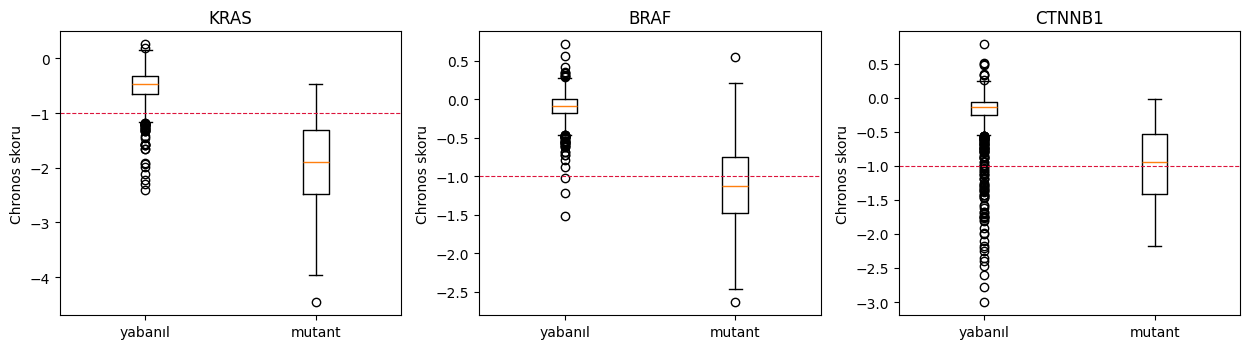

In [5]:
cizilecek = [g for g in ['KRAS', 'BRAF', 'CTNNB1'] if karsilastir(g, yaz=False) is not None]
fig, axes = plt.subplots(1, len(cizilecek), figsize=(4.2 * len(cizilecek), 3.6), squeeze=False)
for ax, g in zip(axes[0], cizilecek):
    d = karsilastir(g, yaz=False)
    ax.boxplot([d[d.mutant == 0].skor.values, d[d.mutant == 1].skor.values],
               tick_labels=['yabanıl', 'mutant'])
    ax.axhline(-1, ls='--', lw=0.8, c='crimson')
    ax.set_title(g); ax.set_ylabel('Chronos skoru')
plt.tight_layout();

## 4. Mutasyon her şeyi açıklamıyor

Kutu grafiklerinde iki şeye birden bakın: kutuların ayrılması ve kutuların *içindeki* yayılma. Mutant grubun içinde bağımlı olmayan hatlar, yabanıl grubun içinde bağımlı hatlar göreceksiniz.

Bunun meşru nedenleri var. Aynı yolağın başka bir üyesi mutant olabilir — KRAS yabanıl ama NRAS mutant bir hat yine RAS yolağına bağımlı olabilir. Gen amplifiye olmuş ama mutasyonsuz olabilir. Ya da hücre o yolağı bırakıp başka bir sürücüye geçmiş olabilir. Mutasyon güçlü bir yordayıcıdır, kesin bir kural değil.

Aşağıdaki tablo bunu sayıyla veriyor: her gen için mutant hatların yüzde kaçı gerçekten bağımlı, ve yabanıl hatların yüzde kaçı bağımlı.

In [6]:
satir = []
for g in ['KRAS', 'BRAF', 'PIK3CA', 'NRAS', 'CTNNB1', 'EGFR']:
    d = karsilastir(g, yaz=False)
    if d is None:
        continue
    m1, m0 = d[d.mutant == 1].skor, d[d.mutant == 0].skor
    satir.append((g, len(m1),
                  round(100 * (m1 < -1).mean(), 1),
                  round(100 * (m0 < -1).mean(), 1)))

print(pd.DataFrame(satir, columns=['gen', 'mutant_hat',
                                   'mutant_bagimli_%', 'yabanil_bagimli_%']).to_string(index=False))

   gen  mutant_hat  mutant_bagimli_%  yabanil_bagimli_%
  KRAS         177              87.0                6.3
  BRAF          91              62.6                0.3
PIK3CA         120              42.5                4.0
  NRAS          62              75.8                0.4
CTNNB1          31              48.4                4.8
  EGFR          13              15.4                4.5


## 5. Ters yön: sentetik letalite

Şimdiye kadarki örnekler hep aynı genin mutasyonuna bakıyordu. Bağımlılığın en ilginç biçimi ise çapraz olanıdır: **bir gendeki kayıp, başka bir geni yaşamsal hale getirir.** Buna sentetik letalite denir ve kanser ilacı geliştirmenin en verimli fikirlerinden biridir, çünkü hedeflenen gen sağlıklı hücrede vazgeçilebilir kalır.

Ders kitabı örneği: tümör baskılayıcı VHL'i kaybetmiş böbrek hücreli karsinom hatları HIF2A yolağına bağımlı hale gelir (HIF2A'nın gen adı EPAS1). İki teknik not. Birincisi, EPAS1 bizim 5.000 genlik ders alt kümemizde yok; onu Drive'daki tam matristen çekiyoruz. Aşağıdaki fonksiyon önce yalnız başlık satırını okuyup istenen sütun adlarını buluyor, sonra `usecols` ile yalnız o sütunları yüklüyor — 430 MB'lık dosyanın tamamı belleğe alınmıyor. İkincisi, karşılaştırmayı dokuya göre yapıyoruz: VHL kaybı işlev *yitiren* mutasyonlarla olur, elimizdeki hotspot matrisi ise işlev kazandıran mutasyonlar içindir. Bu sınırı görmek de dersin parçası.

In [7]:
def tam_matristen(semboller):
    yol = f'{KLASOR}/CRISPRGeneEffect.csv'
    basliklar = pd.read_csv(yol, nrows=0).columns
    istenen = [basliklar[0]] + [c for c in basliklar if c.split(' ')[0] in semboller]
    return pd.read_csv(yol, usecols=istenen, index_col=0)

ek = tam_matristen({'EPAS1'})
d = pd.DataFrame({'skor': ek[ek.columns[0]], 'doku': kunye['OncotreeLineage']}).dropna()

bobrek = d[d.doku == 'Kidney'].skor
digeri = d[d.doku != 'Kidney'].skor
print('EPAS1 (HIF2A)')
print(f'  böbrek hattı: {len(bobrek):4d} | medyan: {bobrek.median():6.2f} | bağımlı oranı: %{100*(bobrek < -1).mean():.1f}')
print(f'  diğer hatlar: {len(digeri):4d} | medyan: {digeri.median():6.2f} | bağımlı oranı: %{100*(digeri < -1).mean():.1f}')

EPAS1 (HIF2A)
  böbrek hattı:   35 | medyan:  -0.06 | bağımlı oranı: %2.9
  diğer hatlar: 1173 | medyan:   0.01 | bağımlı oranı: %0.0


## Kendin dene

Üç görev. Birincisi: 1. bölümdeki okuma sorununu kendi sözlerinizle tek cümlede anlatın — dosya neden doğrudan okunamıyordu ve düzeltilmeseydi analiz ne verirdi? İkincisi: KRAS için mutant ve yabanıl hatların medyan skorlarını ve farkı not edip onkogen bağımlılığını tanımlayın; 4. bölümdeki tabloda yabanıl hatlarda da bağımlılık görülmesinin olası nedenlerinden birini yazın. Üçüncüsü: EPAS1 sonucunu not edip tek cümleyle açıklayın — sentetik letalite ilaç geliştirme açısından neden onkogen bağımlılığından daha değerli olabilir?